In [1]:
import json
from plot_drift_final import plot_drift
from pathlib import Path
import pandas as pd

In [2]:
import os
print(os.getcwd())

/app/river/results_drift


In [3]:

DATASET = "Airplanes"


BASE_DIR = Path("/app/river")

path = BASE_DIR / "transformer" /"config_dataset_plot.json"

with open(path, "r", encoding="utf-8-sig") as f:
    config = json.load(f)
# with open("transformer/config_dataset.json", "r", encoding="utf-8-sig") as f:
#     config = json.load(f)

districts_settings = config[DATASET]["DISTRICTS_SETTINGS"]

df_pred  = pd.read_csv(f"{DATASET}_predictions_2.csv")
df_drift = pd.read_csv(f"{DATASET}_drift_log_2.csv")



In [4]:
# df_drift[df_drift["event_type"]=="centroid"]
df_pred.head(5)

,n_seen,timestamp,district,y,y_hat
0,0,2008-01-01 00:00:00,Global,-3.0,0.000000
1,1,2008-01-01 00:00:00,Global,-19.0,-3.000000
2,2,2008-01-01 00:00:00,Global,-24.0,-10.275522
3,3,2008-01-01 00:00:00,Global,12.0,-13.701357
4,4,2008-01-01 00:00:00,West,24.0,0.000000


In [5]:
print(df_drift[df_drift['event_type']=='centroid'].tail(20) )
df_drift.dtypes

                timestamp  n_seen event_type   district
1690  2008-02-09 00:00:00  352724   centroid     Global
1691  2008-02-09 00:00:00  169012   centroid       West
1692  2008-02-09 00:00:00   47397   centroid    Midwest
1693  2008-02-09 00:00:00  165500   centroid      South
1694  2008-02-09 00:00:00   15238   centroid  Northeast


timestamp       str
n_seen        int64
event_type      str
district        str
dtype: object

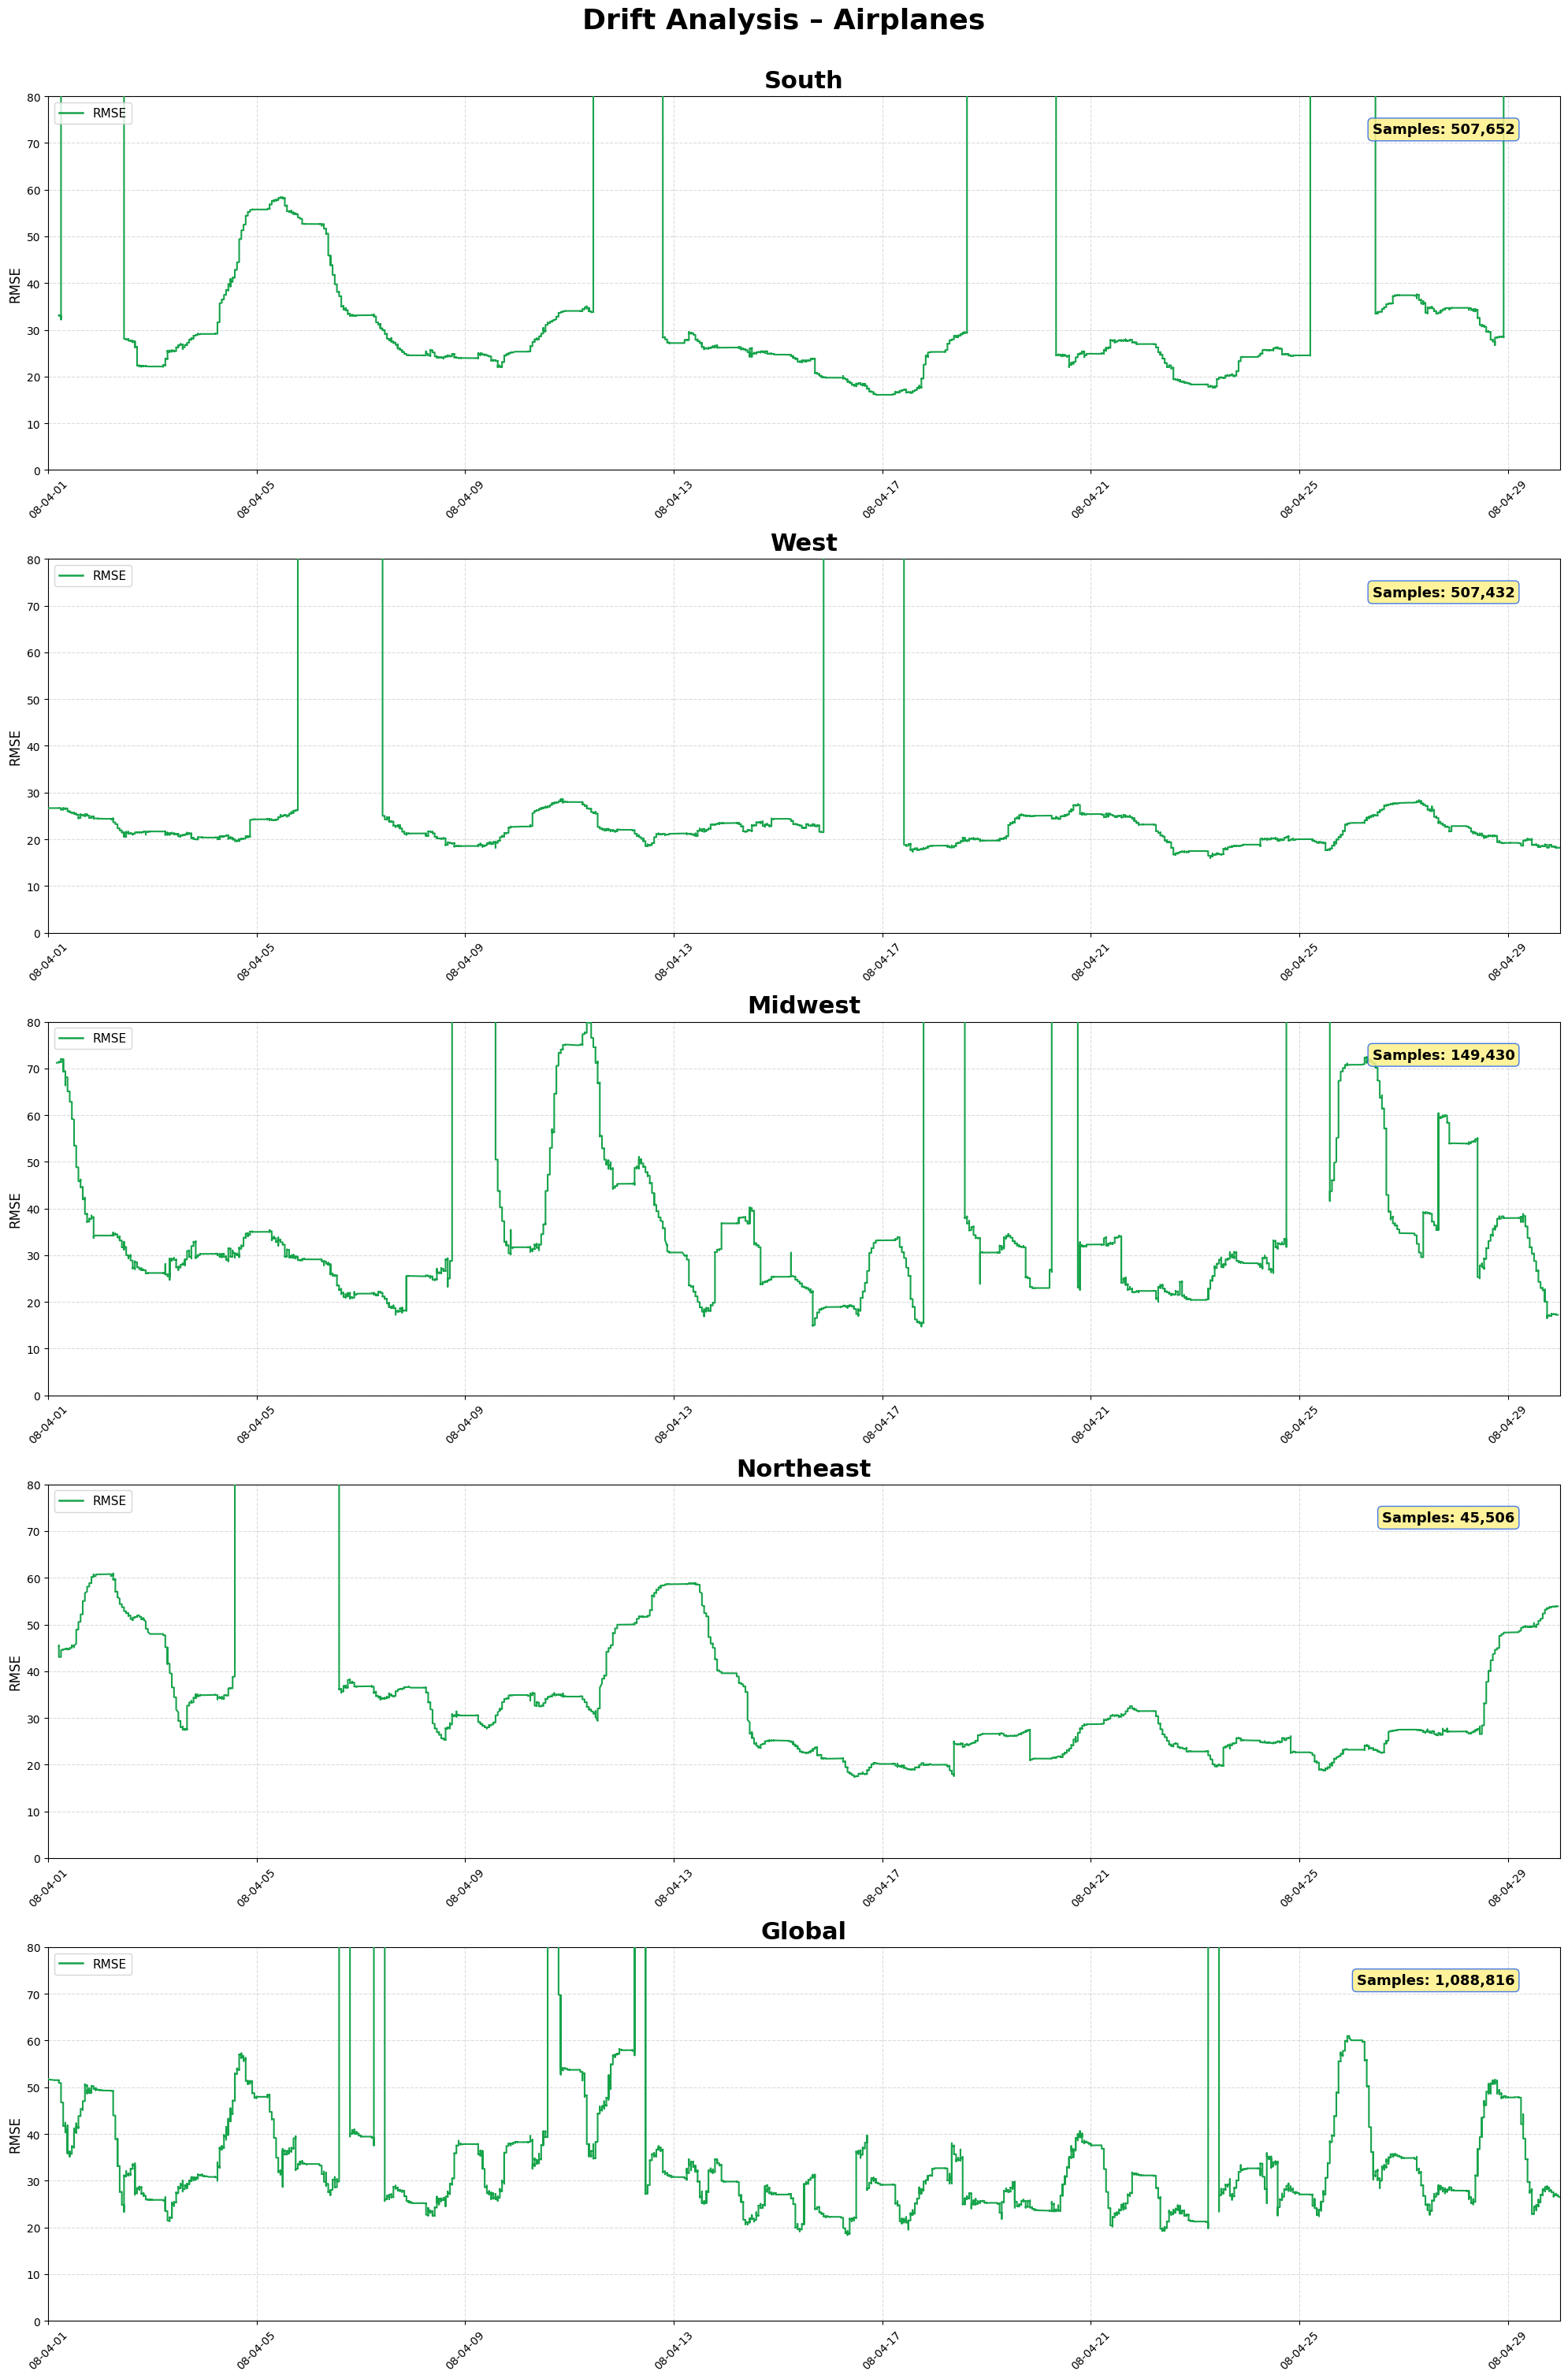

In [6]:
plot_drift(
        df_predictions=df_pred,
        df_drift=df_drift,
        districts_settings=districts_settings,
        dataset=DATASET,
        date_from="2008-04-01",       
        date_to="2008-04-30",           
        save_path=f"plot_drift_{DATASET}.png",
        y_max=80
    )